# FinClaw 数据可视化探索

## 1. 环境准备

In [18]:
import sys
import os
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker
import numpy as np
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# 加载环境变量（向上查找 .env.postgres）
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / ".env.postgres").exists():
        break
    ROOT = ROOT.parent
load_dotenv(ROOT / ".env.postgres")

# 图表中文字体
matplotlib.rcParams["font.family"] = ["PingFang SC", "Heiti TC", "STHeiti",
                                       "Microsoft YaHei", "SimHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 120

# 数据库连接
DSN = (
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"{os.getenv('POSTGRES_HOST','127.0.0.1')}:"
    f"{os.getenv('POSTGRES_PORT','5432')}/"
    f"{os.getenv('POSTGRES_DB')}"
)
engine = create_engine(DSN, pool_pre_ping=True)

def q(sql: str, **kwargs) -> pd.DataFrame:
    """执行 SQL，返回 DataFrame。"""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, **kwargs)

print("连接成功 ✓")

连接成功 ✓


## 2. 市场概览

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

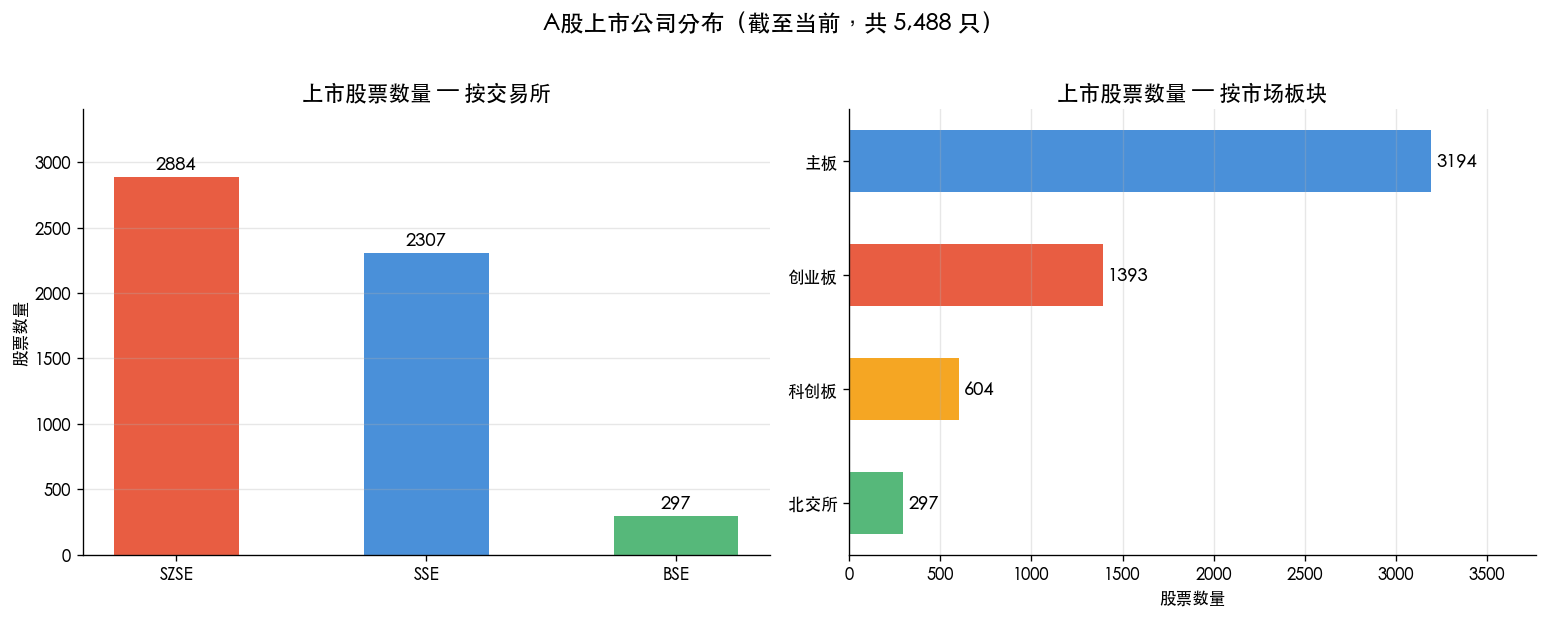

In [19]:
# 按交易所 × 市场统计上市/退市股票数量
df_mkt = q("""
    SELECT
        exchange,
        market,
        list_status,
        COUNT(*) AS cnt
    FROM dim_stock
    GROUP BY exchange, market, list_status
    ORDER BY exchange, market, list_status
""")

# 只看上市中 (L)
df_L = df_mkt[df_mkt["list_status"] == "L"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- 左图：按交易所 --
exch = df_L.groupby("exchange")["cnt"].sum().sort_values(ascending=False)
colors_e = ["#E85D42", "#4A90D9", "#56B87A"]
bars = axes[0].bar(exch.index, exch.values, color=colors_e[:len(exch)], width=0.5)
axes[0].bar_label(bars, fmt="%d", padding=3, fontsize=11)
axes[0].set_title("上市股票数量 — 按交易所", fontsize=13)
axes[0].set_ylabel("股票数量")
axes[0].set_ylim(0, exch.max() * 1.18)
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

# -- 右图：按市场板块 --
mkt = df_L.groupby("market")["cnt"].sum().sort_values(ascending=False)
colors_m = ["#4A90D9","#E85D42","#F5A623","#56B87A","#9B59B6"]
bars2 = axes[1].barh(mkt.index[::-1], mkt.values[::-1],
                     color=colors_m[:len(mkt)][::-1], height=0.55)
axes[1].bar_label(bars2, fmt="%d", padding=3, fontsize=11)
axes[1].set_title("上市股票数量 — 按市场板块", fontsize=13)
axes[1].set_xlabel("股票数量")
axes[1].set_xlim(0, mkt.max() * 1.18)
axes[1].grid(axis="x", alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(f"A股上市公司分布（截至当前，共 {df_L['cnt'].sum():,} 只）",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. 行业分布

/var/folders/3l/jggh76_n62x9pny68g906t580000gn/T/ipykernel_22088/3176745087.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(df_ind))
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Pi

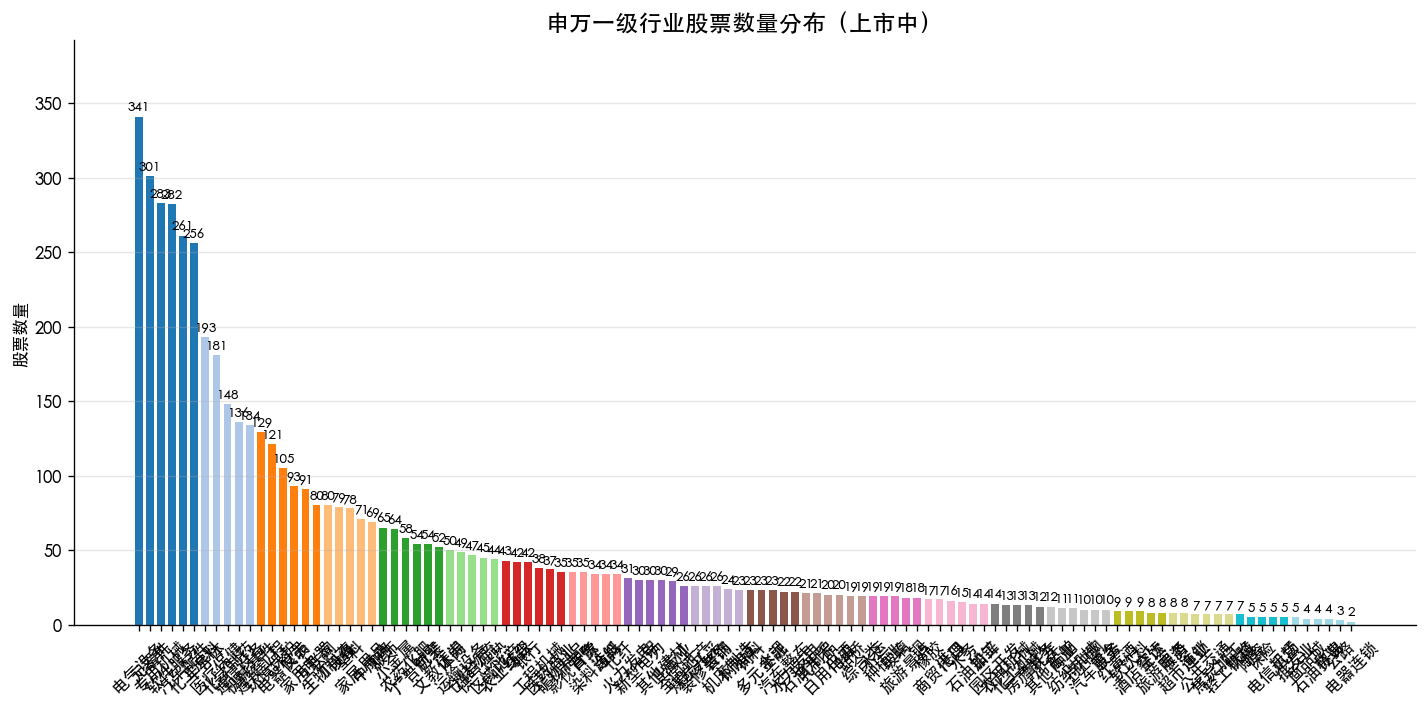

In [20]:
df_ind = q("""
    SELECT industry, COUNT(*) AS cnt
    FROM dim_stock
    WHERE list_status = 'L' AND industry IS NOT NULL
    GROUP BY industry
    ORDER BY cnt DESC
""")

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.get_cmap("tab20", len(df_ind))
colors = [cmap(i) for i in range(len(df_ind))]
bars = ax.bar(df_ind["industry"], df_ind["cnt"], color=colors, width=0.7)
ax.bar_label(bars, fmt="%d", padding=2, fontsize=8)
ax.set_title("申万一级行业股票数量分布（上市中）", fontsize=14)
ax.set_ylabel("股票数量")
ax.set_ylim(0, df_ind["cnt"].max() * 1.15)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. 历年 IPO 数量趋势

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

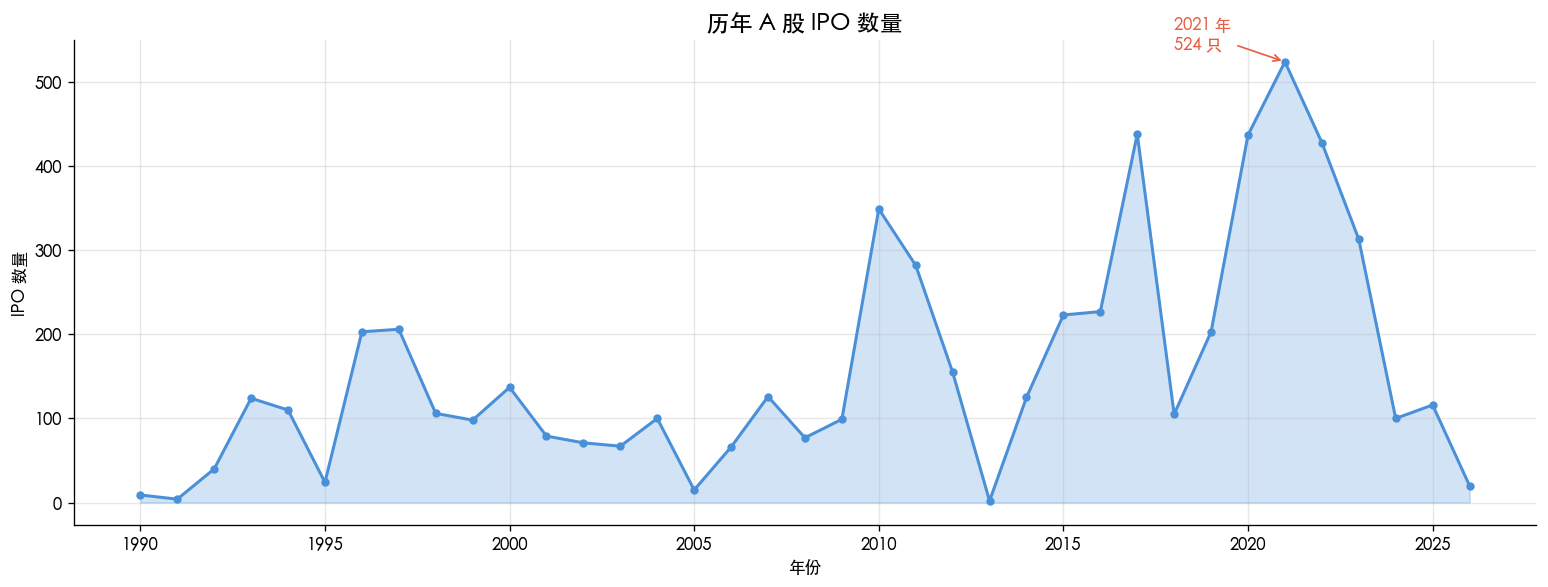

In [21]:
df_ipo = q("""
    SELECT
        EXTRACT(YEAR FROM list_date)::int AS year,
        COUNT(*) AS ipo_cnt
    FROM dim_stock
    WHERE list_date IS NOT NULL AND EXTRACT(YEAR FROM list_date) >= 1990
    GROUP BY year
    ORDER BY year
""")

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(df_ipo["year"], df_ipo["ipo_cnt"], alpha=0.25, color="#4A90D9")
ax.plot(df_ipo["year"], df_ipo["ipo_cnt"], marker="o", markersize=4,
        linewidth=1.8, color="#4A90D9")

# 标注年度最大值
peak = df_ipo.loc[df_ipo["ipo_cnt"].idxmax()]
ax.annotate(f"{int(peak['year'])} 年\n{int(peak['ipo_cnt'])} 只",
            xy=(peak["year"], peak["ipo_cnt"]),
            xytext=(peak["year"] - 3, peak["ipo_cnt"] + 15),
            arrowprops=dict(arrowstyle="->", color="#E85D42"),
            color="#E85D42", fontsize=10)

ax.set_title("历年 A 股 IPO 数量", fontsize=14)
ax.set_xlabel("年份")
ax.set_ylabel("IPO 数量")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. 单股 K 线图（后复权）

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

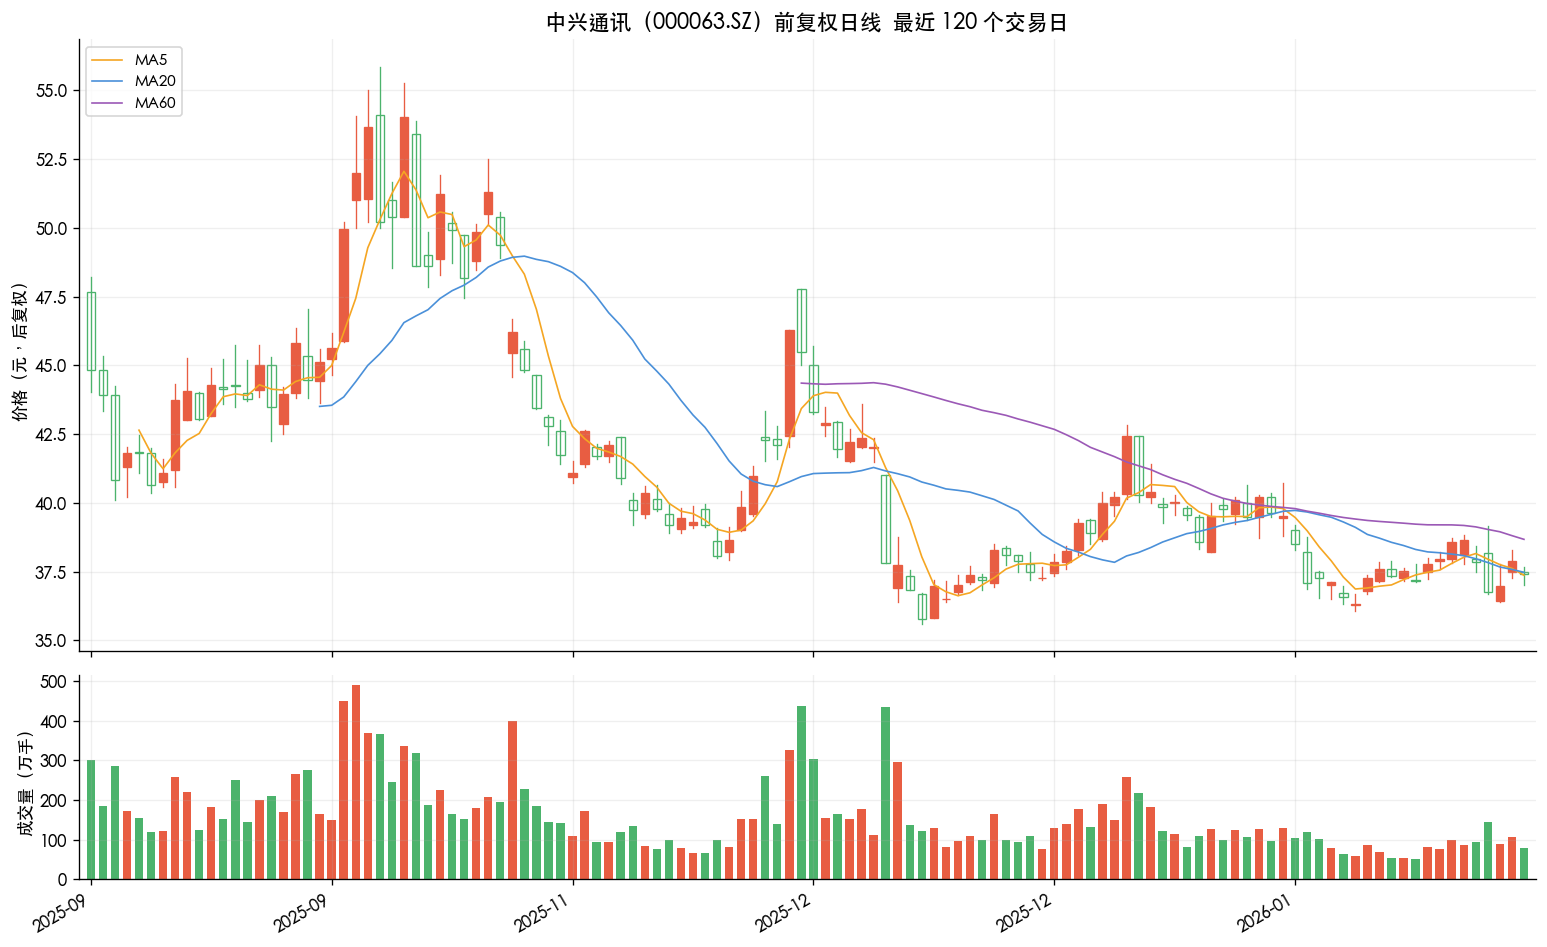

In [28]:
TS_CODE = "000063.SZ"   # 可改为任意股票代码
PERIOD  = 120           # 最近 N 个交易日

df_k = q(f"""
    SELECT trade_date, open, high, low, close, vol
    FROM v_daily_qfq
    WHERE ts_code = '{TS_CODE}'
    ORDER BY trade_date DESC
    LIMIT {PERIOD}
""")
df_k = df_k.sort_values("trade_date").reset_index(drop=True)
df_k["trade_date"] = pd.to_datetime(df_k["trade_date"])

# 获取股票名称
name = q(f"SELECT name FROM dim_stock WHERE ts_code='{TS_CODE}'")["name"].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)

# --- K 线 ---
for i, row in df_k.iterrows():
    up = row["close"] >= row["open"]
    color = "#E85D42" if up else "#4CB36C"
    # 上下影线
    ax1.plot([i, i], [row["low"], row["high"]], color=color, linewidth=0.8)
    # 实体
    body_lo = min(row["open"], row["close"])
    body_hi = max(row["open"], row["close"])
    ax1.add_patch(
        mpatches.Rectangle(
            (i - 0.35, body_lo), 0.7, max(body_hi - body_lo, 0.01),
            facecolor=color if up else "white",
            edgecolor=color, linewidth=0.8
        )
    )

# 5/20/60 日均线
for window, lc in [(5, "#F5A623"), (20, "#4A90D9"), (60, "#9B59B6")]:
    ma = df_k["close"].rolling(window).mean()
    ax1.plot(range(len(df_k)), ma, linewidth=1, color=lc, label=f"MA{window}")

ax1.set_xlim(-1, len(df_k))
ax1.set_title(f"{name}（{TS_CODE}）前复权日线  最近 {PERIOD} 个交易日",
              fontsize=13)
ax1.set_ylabel("价格（元，后复权）")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.2)
ax1.spines[["top","right"]].set_visible(False)

# --- 成交量 ---
colors_v = ["#E85D42" if row["close"] >= row["open"] else "#4CB36C"
            for _, row in df_k.iterrows()]
ax2.bar(range(len(df_k)), df_k["vol"] / 1e4, color=colors_v, width=0.7)
ax2.set_ylabel("成交量（万手）")
ax2.grid(alpha=0.2)
ax2.spines[["top","right"]].set_visible(False)

# X 轴日期标签（每 20 根显示一次）
tick_pos  = list(range(0, len(df_k), 20))
tick_lbl  = [df_k["trade_date"].iloc[i].strftime("%Y-%m") for i in tick_pos]
ax2.set_xticks(tick_pos)
ax2.set_xticklabels(tick_lbl, rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 6. 全市场估值分布快照

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

最新数据日期：2026-03-06


findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family

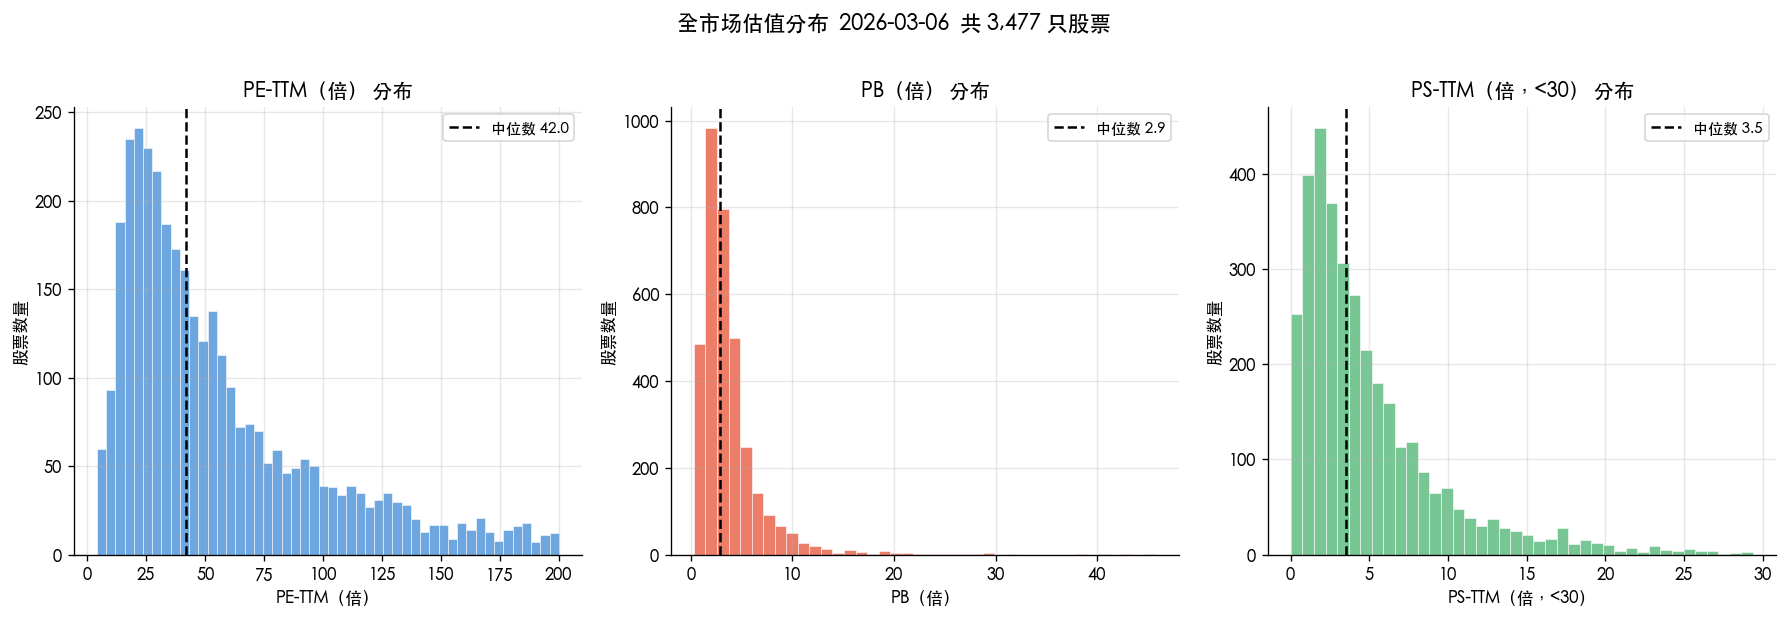

In [23]:
# 取最新有数据的交易日
latest = q("""
    SELECT MAX(trade_date) FROM fact_daily_basic
""")["max"].iloc[0]
print(f"最新数据日期：{latest}")

df_val = q(f"""
    SELECT b.pe_ttm, b.pb, b.ps_ttm, b.dv_ttm,
           b.circ_mv, s.industry
    FROM fact_daily_basic b
    JOIN dim_stock s USING (ts_code)
    WHERE b.trade_date = '{latest}'
      AND s.list_status = 'L'
      AND b.pe_ttm > 0 AND b.pe_ttm < 200   -- 剔除异常值
      AND b.pb  > 0 AND b.pb  < 50
""")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, xlabel, bins, color in [
    (axes[0], "pe_ttm", "PE-TTM（倍）",      50, "#4A90D9"),
    (axes[1], "pb",     "PB（倍）",            40, "#E85D42"),
    (axes[2], "ps_ttm", "PS-TTM（倍，<30）",  40, "#56B87A"),
]:
    data = df_val[col].dropna()
    if col == "ps_ttm":
        data = data[data < 30]
    ax.hist(data, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    med = data.median()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.5,
               label=f"中位数 {med:.1f}")
    ax.set_title(f"{xlabel} 分布", fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("股票数量")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle(f"全市场估值分布  {latest}  共 {len(df_val):,} 只股票",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. 市值分布

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

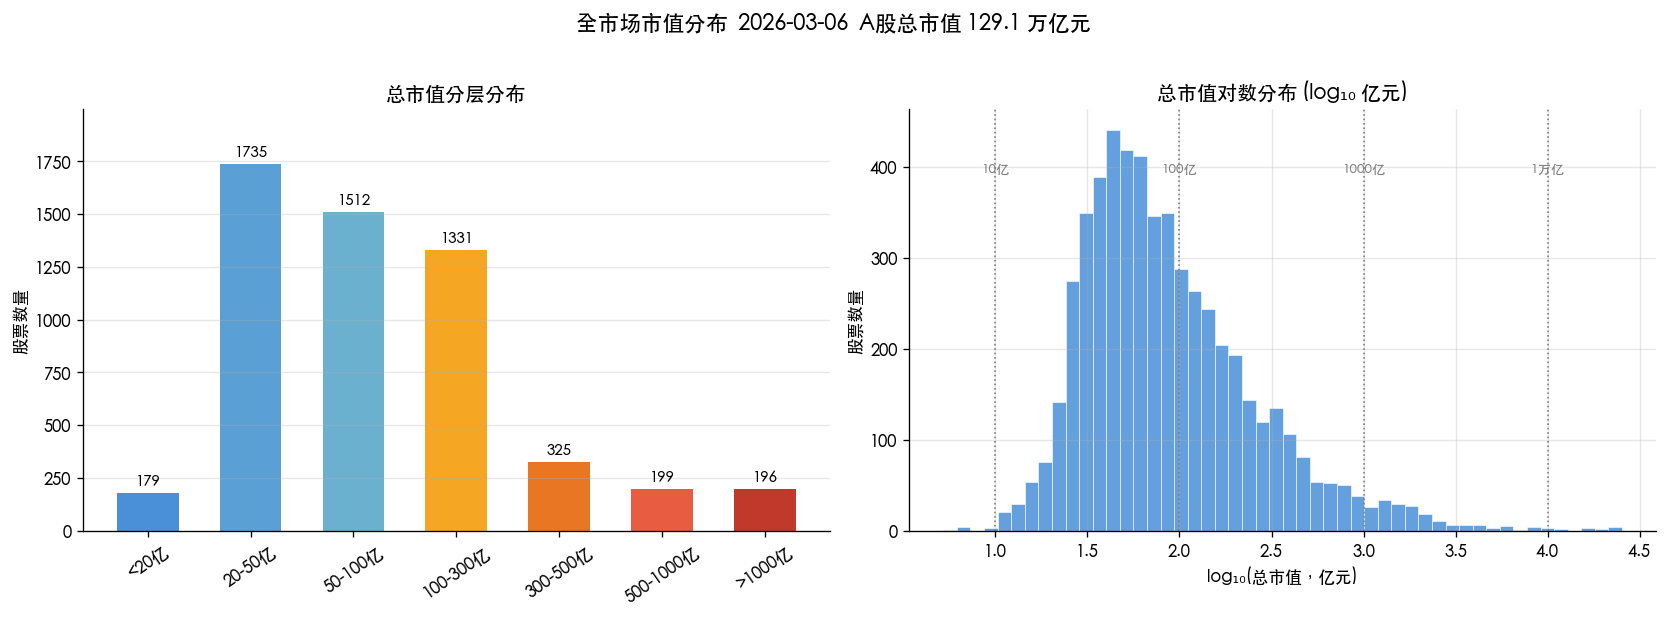

In [24]:
df_mv = q(f"""
    SELECT b.total_mv / 1e4 AS total_mv_yi,   -- 亿元
           b.circ_mv  / 1e4 AS circ_mv_yi,
           s.market, s.industry
    FROM fact_daily_basic b
    JOIN dim_stock s USING (ts_code)
    WHERE b.trade_date = '{latest}'
      AND s.list_status = 'L'
      AND b.total_mv > 0
""")

# 市值分级
bins_mv = [0, 20, 50, 100, 300, 500, 1000, np.inf]
labels_mv = ["<20亿","20-50亿","50-100亿",
             "100-300亿","300-500亿","500-1000亿",">1000亿"]
df_mv["tier"] = pd.cut(df_mv["total_mv_yi"], bins=bins_mv, labels=labels_mv)
tier_cnt = df_mv["tier"].value_counts().reindex(labels_mv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- 左图：市值分级柱状图 --
colors_t = ["#4A90D9","#5BA0D5","#6CB0D0","#F5A623","#E87623","#E85D42","#C0392B"]
bars = axes[0].bar(labels_mv, tier_cnt.values, color=colors_t, width=0.6)
axes[0].bar_label(bars, fmt="%d", padding=3, fontsize=9)
axes[0].set_title("总市值分层分布", fontsize=12)
axes[0].set_ylabel("股票数量")
axes[0].set_ylim(0, tier_cnt.max() * 1.15)
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

# -- 右图：总市值对数分布 --
log_mv = np.log10(df_mv["total_mv_yi"].dropna())
axes[1].hist(log_mv, bins=50, color="#4A90D9", alpha=0.85,
             edgecolor="white", linewidth=0.4)
axes[1].set_title("总市值对数分布 (log₁₀ 亿元)", fontsize=12)
axes[1].set_xlabel("log₁₀(总市值，亿元)")
axes[1].set_ylabel("股票数量")
# 标注常见刻度
for val, lbl in [(1,"10亿"),(2,"100亿"),(3,"1000亿"),(4,"1万亿")]:
    axes[1].axvline(val, linestyle=":", color="gray", linewidth=1)
    axes[1].text(val, axes[1].get_ylim()[1]*0.85, lbl,
                 ha="center", fontsize=8, color="gray")
axes[1].grid(alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

total_mktcap = df_mv["total_mv_yi"].sum() / 1e4  # 万亿
plt.suptitle(f"全市场市值分布  {latest}  A股总市值 {total_mktcap:.1f} 万亿元",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. 行业近期涨跌幅（近 20 / 60 交易日）

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

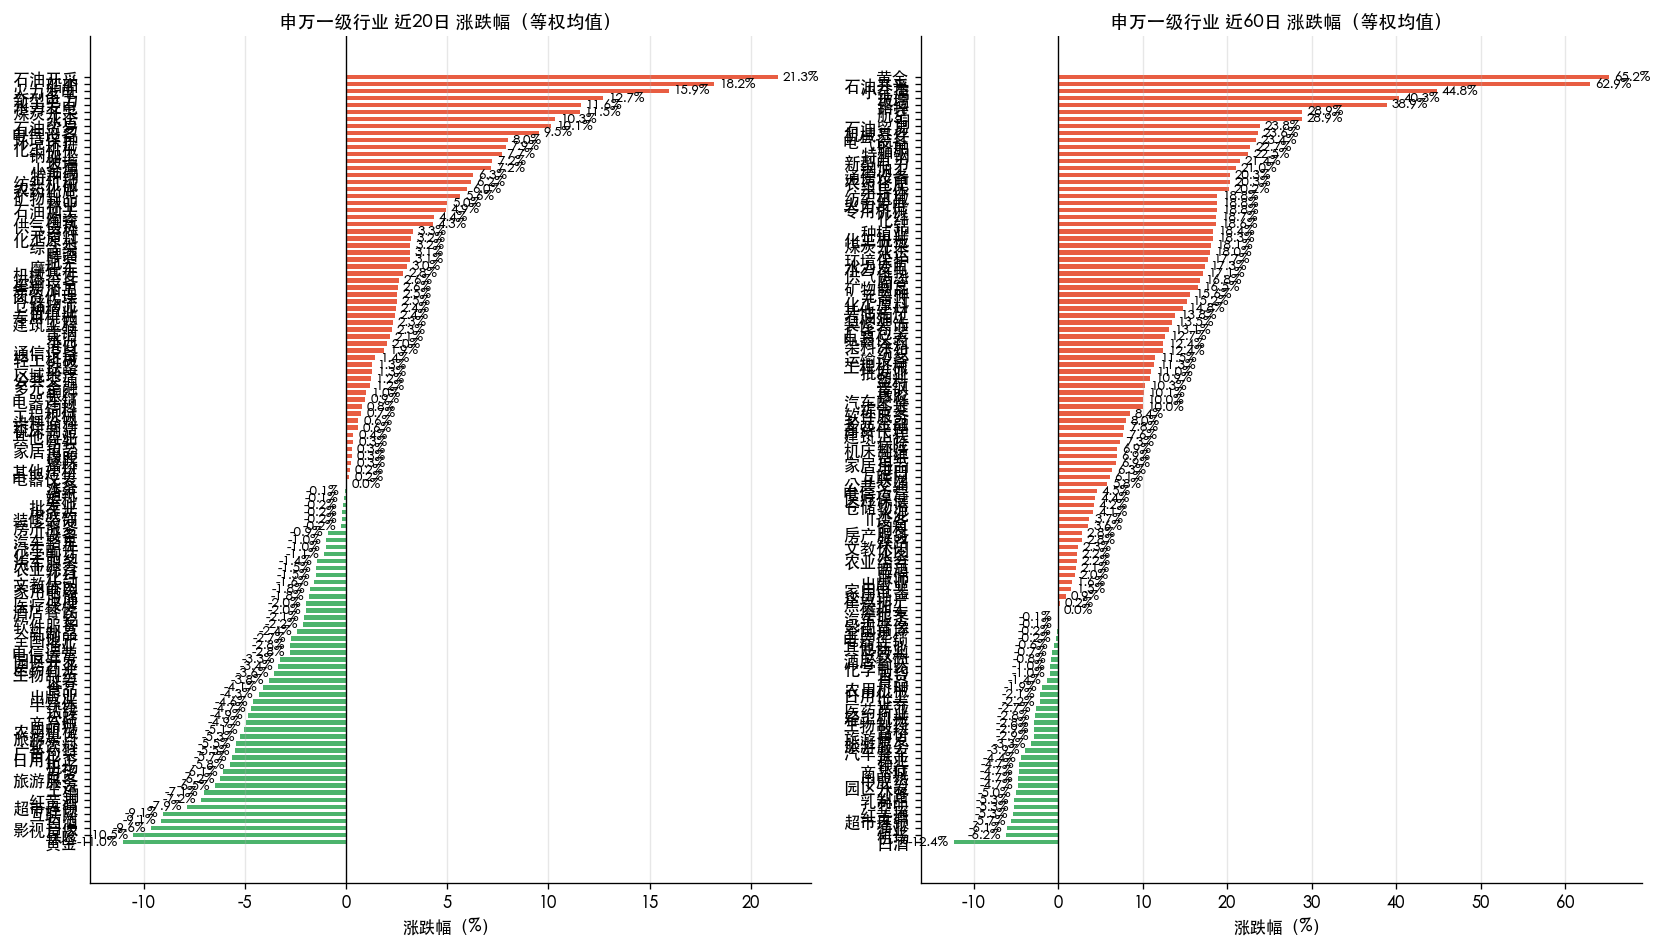

In [25]:
def ind_return(n_days: int) -> pd.Series:
    """计算各行业近 n_days 个交易日等权平均涨跌幅。"""
    df = q(f"""
        WITH ranked AS (
            SELECT d.ts_code, d.trade_date, d.close,
                   ROW_NUMBER() OVER (PARTITION BY d.ts_code
                                     ORDER BY d.trade_date DESC) AS rn
            FROM fact_daily d
            JOIN dim_stock s USING (ts_code)
            WHERE s.list_status = 'L'
        ),
        latest AS  (SELECT ts_code, close FROM ranked WHERE rn = 1),
        oldest AS  (SELECT ts_code, close FROM ranked WHERE rn = {n_days})
        SELECT s.industry,
               AVG((l.close - o.close) / NULLIF(o.close, 0) * 100) AS pct_chg
        FROM latest l
        JOIN oldest o USING (ts_code)
        JOIN dim_stock s USING (ts_code)
        WHERE s.industry IS NOT NULL
        GROUP BY s.industry
        ORDER BY pct_chg DESC
    """)
    return df.set_index("industry")["pct_chg"]

ret20 = ind_return(20)
ret60 = ind_return(60)

df_ir = pd.DataFrame({"近20日": ret20, "近60日": ret60}).sort_values("近20日", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, col, color_pos, color_neg in [
    (axes[0], "近20日", "#E85D42", "#4CB36C"),
    (axes[1], "近60日", "#E85D42", "#4CB36C"),
]:
    vals  = df_ir[col].sort_values(ascending=True)
    colors = [color_pos if v >= 0 else color_neg for v in vals]
    bars = ax.barh(vals.index, vals.values, color=colors, height=0.65)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_title(f"申万一级行业 {col} 涨跌幅（等权均值）", fontsize=11)
    ax.set_xlabel("涨跌幅（%）")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 9. 换手率 vs 涨跌幅 散点图（最新一日）

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

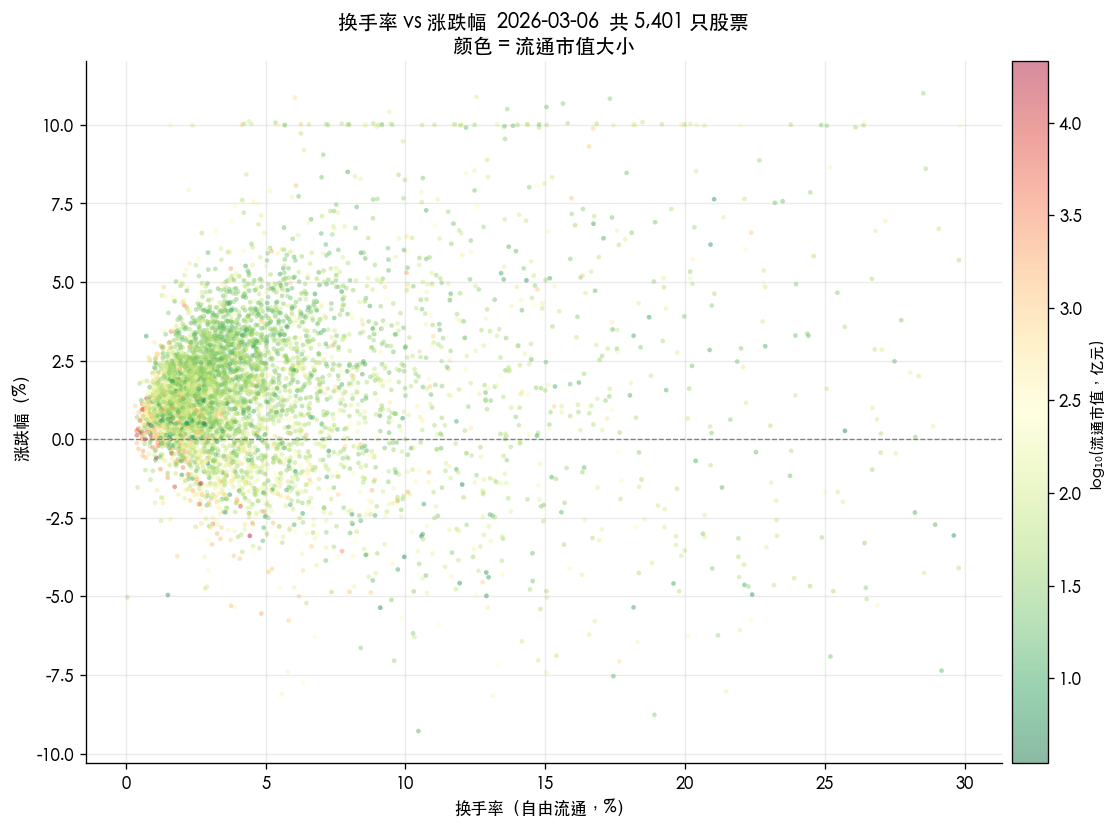

In [26]:
df_sc = q(f"""
    SELECT
        d.pct_chg,
        b.turnover_rate_f,
        b.circ_mv / 1e4 AS circ_mv_yi,
        s.industry
    FROM fact_daily d
    JOIN fact_daily_basic b USING (ts_code, trade_date)
    JOIN dim_stock s USING (ts_code)
    WHERE d.trade_date = '{latest}'
      AND s.list_status = 'L'
      AND b.turnover_rate_f BETWEEN 0.01 AND 30
      AND d.pct_chg BETWEEN -11 AND 11
      AND b.circ_mv > 0
""")

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    df_sc["turnover_rate_f"],
    df_sc["pct_chg"],
    c=np.log10(df_sc["circ_mv_yi"].clip(lower=0.1)),
    cmap="RdYlGn_r",
    s=8, alpha=0.45, linewidths=0
)
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("log₁₀(流通市值，亿元)", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("换手率（自由流通，%）")
ax.set_ylabel("涨跌幅（%）")
ax.set_title(f"换手率 vs 涨跌幅  {latest}  共 {len(df_sc):,} 只股票\n颜色 = 流通市值大小",
             fontsize=12)
ax.grid(alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 10. 全市场日成交额趋势（近两年）

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family

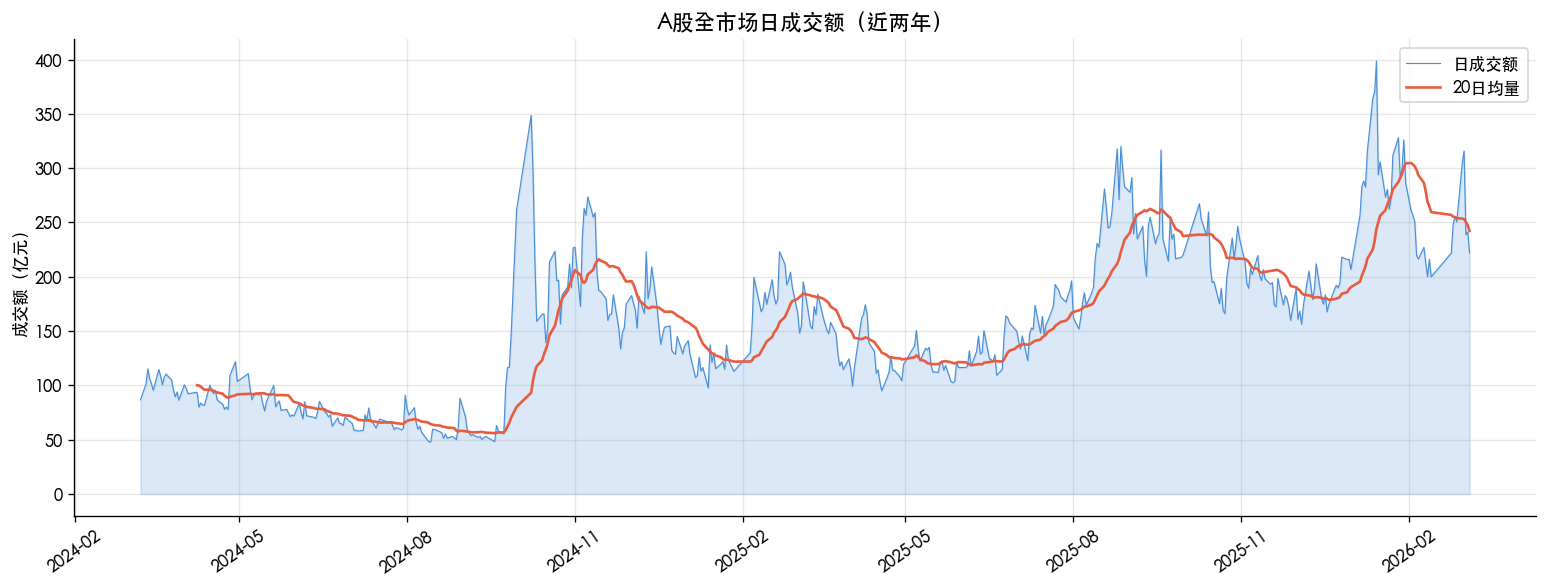

In [27]:
df_vol = q("""
    SELECT
        trade_date,
        SUM(amount) / 1e7 AS amount_yi   -- 千元 → 亿元
    FROM fact_daily
    WHERE trade_date >= CURRENT_DATE - INTERVAL '2 years'
    GROUP BY trade_date
    ORDER BY trade_date
""")
df_vol["trade_date"] = pd.to_datetime(df_vol["trade_date"])
df_vol["ma20"] = df_vol["amount_yi"].rolling(20).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(df_vol["trade_date"], df_vol["amount_yi"],
                alpha=0.2, color="#4A90D9")
ax.plot(df_vol["trade_date"], df_vol["amount_yi"],
        color="#4A90D9", linewidth=0.7, label="日成交额")
ax.plot(df_vol["trade_date"], df_vol["ma20"],
        color="#E85D42", linewidth=1.6, label="20日均量")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis="x", rotation=35)
ax.set_title("A股全市场日成交额（近两年）", fontsize=13)
ax.set_ylabel("成交额（亿元）")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()